In [1]:
# 7-4-2026

In [19]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import shap

In [20]:
# same architecture as training notebook, needed to load state dict correctly
class Encoder(nn.Module):
    def __init__(self, input_dim=33, embed_dim=8, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, embed_dim)
        )

    def forward(self, x):
        return self.net(x)


class PredictionHead(nn.Module):
    def __init__(self, embed_dim=8):
        super().__init__()
        # input is [e_i, e_j, e_i - e_j], outputs spearman pred
        self.net = nn.Sequential(
            nn.Linear(embed_dim * 3, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, e_i, e_j):
        diff = e_i - e_j
        x = torch.cat([e_i, e_j, diff], dim=-1)
        return self.net(x).squeeze(-1)


class TransferModel(nn.Module):
    def __init__(self, input_dim=33, embed_dim=8):
        super().__init__()
        self.encoder = Encoder(input_dim, embed_dim)
        self.head = PredictionHead(embed_dim)

    def forward(self, desc_i, desc_j):
        e_i = self.encoder(desc_i)
        e_j = self.encoder(desc_j)
        return self.head(e_i, e_j)

In [21]:
device = torch.device("cpu")
model = TransferModel().to(device)
model.load_state_dict(torch.load("../training/transfer_model.pt", map_location=device))
model.eval()  # turn of dropout so shap gets determiinstic outputs

TransferModel(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=33, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=32, out_features=8, bias=True)
    )
  )
  (head): PredictionHead(
    (net): Sequential(
      (0): Linear(in_features=24, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)

In [22]:
transfer_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
transfer_matrix.set_index("Unnamed: 0", inplace=True)
transfer_matrix.index.name = None
transfer_matrix.index = transfer_matrix.index.astype(int)
transfer_matrix.columns = transfer_matrix.columns.astype(int)
transfer_matrix.head()

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770


In [23]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors.set_index("domain_id", inplace=True)
descriptors.index = descriptors.index.astype(int)
descriptors.head()

,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,ndvi_mean,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
domain_id,,,,,,,,,,,,,,,,,,,,,
0,11.229313,5.895861,19.746270,2.516127,1.052111,3.968697,302.43317,4.790887,307.46002,0.641714,...,0.479085,547.38410,1932.2546,1112.03370,0.067789,0.469590,0.097816,0.081824,0.728328,6
1,6.742952,3.144529,10.522034,1.406203,0.511182,2.132592,301.80650,4.735351,305.51370,0.796118,...,0.499585,338.66165,1157.0903,705.89197,0.063071,0.392797,0.108795,0.013560,0.218936,7
2,21.599873,10.565010,36.654785,4.066474,0.951055,5.291819,303.89624,6.380806,311.61792,0.242577,...,0.257699,3360.49340,8181.0723,8625.16300,0.162555,0.925012,0.219152,0.032987,0.602900,7
3,4.211150,2.716757,7.958644,3.166607,1.505368,5.099028,286.08792,10.954839,299.41890,0.550528,...,0.411259,328.76685,739.6544,901.44635,0.041860,0.274789,0.000000,0.001419,0.365885,3
4,2.564834,3.033652,6.938553,3.300411,1.380530,5.114551,273.42078,16.251247,293.80110,0.315671,...,0.447848,669.05206,2307.7700,1315.65490,0.185203,1.571907,0.090595,0.007227,0.615066,5


In [24]:
active_ids = transfer_matrix.index.tolist()
descriptors_active = descriptors.loc[active_ids]

# same holdout split used in training, needed to refit scaler the same way
holdout_ids = [45, 46, 47, 49]
train_ids = [d for d in active_ids if d not in holdout_ids]

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_desc = descriptors_active.loc[train_ids]
scaler.fit(train_desc)

desc_scaled = pd.DataFrame(
    scaler.transform(descriptors_active),
    index=descriptors_active.index,
    columns=descriptors_active.columns
)

In [26]:
# all ordered pairs including diagonal, this is the background set for shap
all_pairs = [(i, j) for i in active_ids for j in active_ids]

# concat desc_i and desc_j into one 66-dim row per pair
background_rows = []
for i, j in all_pairs:
    row = np.concatenate([desc_scaled.loc[i].values, desc_scaled.loc[j].values])
    background_rows.append(row)

background_data = np.array(background_rows, dtype=np.float32)

In [27]:
background_data.shape

(1156, 66)

In [28]:
class WrappedModel(nn.Module):
    def __init__(self, model, input_dim=33):
        super().__init__()
        self.model = model
        self.input_dim = input_dim

    def forward(self, x):
        # first 33 cols are desc_i, next 33 are desc_j
        desc_i = x[:, :self.input_dim]
        desc_j = x[:, self.input_dim:]
        out = self.model(desc_i, desc_j)
        return out.unsqueeze(-1)  # shap wants (batch, 1), not flat (batch,)


wrapped_model = WrappedModel(model)
wrapped_model.eval()

WrappedModel(
  (model): TransferModel(
    (encoder): Encoder(
      (net): Sequential(
        (0): Linear(in_features=33, out_features=32, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=32, out_features=8, bias=True)
      )
    )
    (head): PredictionHead(
      (net): Sequential(
        (0): Linear(in_features=24, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=1, bias=True)
      )
    )
  )
)

In [ ]:
# wrapped output should exactly match original model output
background_tensor = torch.tensor(background_data, dtype=torch.float32)

In [30]:
with torch.no_grad():
    original_preds = model(background_tensor[:, :33], background_tensor[:, 33:])
    wrapped_preds = wrapped_model(background_tensor)

In [31]:
with torch.no_grad():
    wrapped_preds = wrapped_model(background_tensor)
print(wrapped_preds.shape)  # should be (1156, 1)

torch.Size([1156, 1])


In [ ]:
import copy

def strip_dropout(module):
    # swap every dropout layer for identity, since eval mode makes it a no-op anyway
    # this just removes the op shap trips on
    for name, child in module.named_children():
        if isinstance(child, nn.Dropout):
            setattr(module, name, nn.Identity())
        else:
            strip_dropout(child)
    return module

shap_model = copy.deepcopy(model)
strip_dropout(shap_model)
shap_model.eval()

print(shap_model)

TransferModel(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=33, out_features=32, bias=True)
      (1): ReLU()
      (2): Identity()
      (3): Linear(in_features=32, out_features=8, bias=True)
    )
  )
  (head): PredictionHead(
    (net): Sequential(
      (0): Linear(in_features=24, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)


In [ ]:
wrapped_model = WrappedModel(shap_model)
wrapped_model.eval()

explainer = shap.DeepExplainer(wrapped_model, background_tensor)

shap_values = explainer.shap_values(background_tensor, check_additivity=False)
print(np.array(shap_values).shape)
# good, outputted correct shape

(1156, 66, 1)


In [36]:
sv = np.array(shap_values)
sv = sv.squeeze(-1)  # drop trailing output dim, now (1156, 66)
print(sv.shape)  # should be (1156, 66)

(1156, 66)


In [37]:
# src = domain i (source), tgt = domain j (target)
desc_cols = descriptors_active.columns.tolist()
feature_names = [f"src_{c}" for c in desc_cols] + [f"tgt_{c}" for c in desc_cols]

mean_abs_shap = np.abs(sv).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df.head(20))

                     feature  mean_abs_shap
34               tgt_vpd_std       0.009913
60     tgt_cams_frpfire_mean       0.008642
40           tgt_t2m_max_std       0.006445
27     src_cams_frpfire_mean       0.006376
55             tgt_swvl4_std       0.006082
45               tgt_tp_mean       0.005563
49          tgt_fwi_mean_std       0.005510
58           tgt_gwis_ba_std       0.005294
1                src_vpd_std       0.005263
48         tgt_fwi_mean_mean       0.005221
64  tgt_land_cover_diversity       0.005086
39          tgt_t2m_max_mean       0.005049
16          src_fwi_mean_std       0.004919
14                src_tp_p90       0.004880
41           tgt_t2m_max_p90       0.004638
52             tgt_swvl1_std       0.004613
51            tgt_swvl1_mean       0.004607
62      tgt_cams_frpfire_p90       0.004594
25           src_gwis_ba_std       0.004424
7            src_t2m_max_std       0.004366


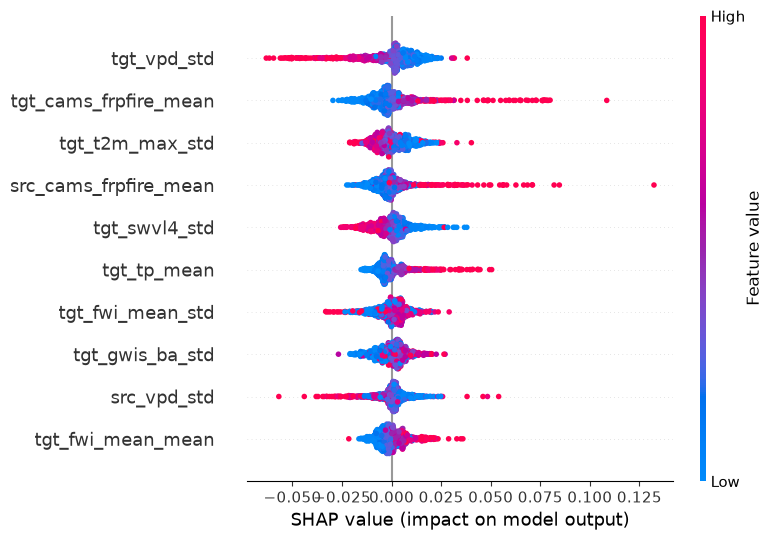

In [39]:
import matplotlib.pyplot as plt

shap.summary_plot(sv, background_data, feature_names=feature_names, show=False, max_display=10)
plt.tight_layout()
plt.show()

In [ ]:
std_feats = ["tgt_vpd_std", "tgt_t2m_max_std", "tgt_swvl4_std", "tgt_fwi_mean_std", "tgt_gwis_ba_std"]

for f in std_feats:
    idx = feature_names.index(f)
    corr = np.corrcoef(background_data[:, idx], sv[:, idx])[0, 1] # corr between featue value and shap value
    print(f"{f}: {corr:.3f}")

tgt_vpd_std: -0.836
tgt_t2m_max_std: -0.611
tgt_swvl4_std: -0.815
tgt_fwi_mean_std: 0.216
tgt_gwis_ba_std: 0.390


In [ ]:
# one thing i can interpret from the beeswarm which to me is really cool: most of the highest importance features are std, 
#   and especially for target. that means that when the target domain itself is environmentally erratic, 
#   it makes it harder for another domain's model to cleanly map onto it
# most of the std features here have blue dots (low environmental variance) leading to increased transferability

In [46]:
# grab every feature name ending in std, both src and tgt sides
std_features = [f for f in feature_names if f.endswith("std")]

for f in std_features:
    idx = feature_names.index(f)
    corr = np.corrcoef(background_data[:, idx], sv[:, idx])[0, 1]
    print(f"{f}: {corr:.3f}")

src_vpd_std: -0.454
src_ws10_std: -0.274
src_t2m_max_std: 0.618
src_ndvi_std: 0.773
src_tp_std: -0.399
src_fwi_mean_std: -0.036
src_swvl1_std: 0.642
src_swvl4_std: -0.045
src_gwis_ba_std: 0.211
src_cams_frpfire_std: -0.576
tgt_vpd_std: -0.836
tgt_ws10_std: 0.153
tgt_t2m_max_std: -0.611
tgt_ndvi_std: -0.650
tgt_tp_std: -0.733
tgt_fwi_mean_std: 0.216
tgt_swvl1_std: 0.666
tgt_swvl4_std: -0.815
tgt_gwis_ba_std: 0.390
tgt_cams_frpfire_std: -0.389


In [ ]:
base_vars = []
for f in feature_names:
    if f.endswith("std"):
        var = f.replace("src_", "").replace("tgt_", "")
        if var not in base_vars:
            base_vars.append(var)

for var in base_vars:
    src_idx = feature_names.index(f"src_{var}")
    tgt_idx = feature_names.index(f"tgt_{var}")
    src_corr = np.corrcoef(background_data[:, src_idx], sv[:, src_idx])[0, 1]
    tgt_corr = np.corrcoef(background_data[:, tgt_idx], sv[:, tgt_idx])[0, 1]
    print(f"{var}: src {src_corr:.3f}, tgt {tgt_corr:.3f}")

vpd_std: src -0.454, tgt -0.836
ws10_std: src -0.274, tgt 0.153
t2m_max_std: src 0.618, tgt -0.611
ndvi_std: src 0.773, tgt -0.650
tp_std: src -0.399, tgt -0.733
fwi_mean_std: src -0.036, tgt 0.216
swvl1_std: src 0.642, tgt 0.666
swvl4_std: src -0.045, tgt -0.815
gwis_ba_std: src 0.211, tgt 0.390
cams_frpfire_std: src -0.576, tgt -0.389
